In [14]:
import pandas as pd
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np


In [2]:
data_path = "/Users/sana/Downloads/STAT390/Data/CAR_-_EP_Flow_Activity_Queue__Agent_Names"

In [55]:
folder = Path(data_path)
files = sorted(list(folder.glob("*.csv")) + list(folder.glob("*.xlsx")))

df_main = pd.DataFrame(columns=['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name', 'Activity Start Timestamp', 
                                'Queue Name', 'Agent Name', 'Termination Reason'])
df_main

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason


In [56]:
i=0
for f in files:
    i = i + 1
    if f.suffix.lower() == ".csv":
        df = pd.read_csv(f, header=2, dtype=str, engine="python", skip_blank_lines=False)
    else:  # .xlsx
        df = pd.read_excel(f, sheet_name=0, header=2, dtype=str)
    df_main = pd.concat([df_main, df], ignore_index=True)
    print(i, f.stem, df.shape)

1 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-16 to 3-22-25 (45326, 8)
2 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 3-30 to 4-5-25 (45072, 8)
3 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-13 to 4-19-25 (41088, 8)
4 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-20 to 4-26-25 (46686, 8)
5 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-27 to 5-3-25 (44169, 8)
6 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 4-6 to 4-12-25 (46630, 8)
7 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-11 to 5-17-25 (43268, 8)
8 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-18 to 5-24-25 (45104, 8)
9 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-25 to 5-31-25 (36851, 8)
10 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 5-4 to 5-10-25 (43955, 8)
11 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-1 to 6-7-25 (44523, 8)
12 CAR - EP, Flow, Activity, Queue, &amp; Agent Names 6-15 to 6-21-25 (37234, 8)
13 CAR - EP, Flow, Activity, Queue, &amp; A

In [57]:
df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors="coerce")
# Creating a new column 'hour' as it will be useful to visualize peak calling hours
#df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour
#df_main["weekday"] = df_main["Activity Start Timestamp"].dt.day_name()

/var/folders/js/ymz6mb411xbdbhb1g8hh6rvr0000gn/T/ipykernel_18214/19692311.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main["Activity Start Timestamp"] = pd.to_datetime(df_main["Activity Start Timestamp"], errors="coerce")


In [58]:
df_main.head()
#df_main['Contact Session ID'].nunique()


,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
1,ced63a4a-89f4-4e11-94b3-447a01cd34cb,NaN,LACMain,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
2,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-16 00:40:10,NaN,NaN,NaN
3,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,LACMain,NaN,2025-03-16 00:40:10,NaN,NaN,NaN
4,ced63a4a-89f4-4e11-94b3-447a01cd34cb,Main Number Telephony EP,NaN,NaN,2025-03-16 00:40:12,NaN,NaN,Customer Left


In [59]:
# Create sequential call_id correctly

# 1) Sort df_main properly (and assign)
df_main = df_main.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
).reset_index(drop=True)

# 2) Create sequential call_id (one id per Contact Session ID)
# Option A (your original style, safe now because df_main is sorted):
df_main['call_id'] = (
    (df_main['Contact Session ID'] != df_main['Contact Session ID'].shift())
    .cumsum()
)
'''
df_main.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
)
df_main_sorted = df_main['call_id'] = (
    (df_main['Contact Session ID'] != 
     df_main['Contact Session ID'].shift())
    .cumsum()
)
'''

# REORDER COLUMNS
column_order = [
    'call_id',
    'Contact Session ID',
    'EP Name',
    'Flow Name',
    'Activity Name',
    'Activity Start Timestamp',
    'Queue Name',
    'Agent Name',
    'Termination Reason']
df_main = df_main[column_order]

df_main.head()

,call_id,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,NaN,NaN,2025-03-17 16:53:15,NaN,NaN,NaN
1,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,NaN,LACMain,NaN,2025-03-17 16:53:15,NaN,NaN,NaN
2,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-17 16:53:15,NaN,NaN,NaN
3,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,LACMain,NaN,2025-03-17 16:53:16,NaN,NaN,NaN
4,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,NaN,MainMenu,2025-03-17 16:53:26,NaN,NaN,NaN


In [ ]:
# Make sure rows are sorted by call/session and timestamp
df_main = df_main.sort_values(['call_id', 'Activity Start Timestamp']).reset_index(drop=True)

# next termination reason if you need it
df_main['next_termination_reason'] = (
    df_main.groupby('call_id')['Termination Reason'].shift(-1)
)




In [61]:
df_main['EP Name'].value_counts(dropna=False)

EP Name
Main Number Telephony EP                    445983
NaN                                         312347
Legal Menu Telephony EP                      92192
Pre-Legal Menu Seniors Menu Telephony EP     87087
Closed Queue Menu Telephony EP               62244
All LAC Queues Telephony EP                  54574
Courtesy Callback Telephony EP               38286
Closed Hours-Holidays Menu Telephony EP      27779
Other Legal Menu Telephony EP                27763
Legal Housing Menu Telephony EP              26564
Intake Outdial EP                            22741
Farmworker Main Number Telephony EP          22363
Legal Family Menu Telephony EP               22321
Legal Benefits Menu Telephony EP              3081
Legal HIV Menu Telephony EP                   2875
Legal Immigration Menu Telephony EP           2630
Legal Employment Menu Telephony EP            2250
Name: count, dtype: int64

In [62]:
df_main_menu = df_main[df_main['EP Name'] == 'Main Number Telephony EP'].copy()

In [ ]:
# Step 1: Get all unique Contact Session IDs that went through the main number EP
main_calls = df_main_menu['Contact Session ID'].unique()

# Step 2: Filter df_main to only include those same sessions
df_main_sessions = df_main[df_main['Contact Session ID'].isin(main_calls)].copy()

# Step 3: sort chronologically to see the call flow order
df_main_menu_sorted = df_main_sessions.sort_values(
    by=['Contact Session ID', 'Activity Start Timestamp']
).reset_index(drop=True)

In [64]:
df_main_menu_sorted.head()

,call_id,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,next_termination_reason
0,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,NaN,NaN,2025-03-17 16:53:15,NaN,NaN,NaN,NaN
1,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,NaN,LACMain,NaN,2025-03-17 16:53:15,NaN,NaN,NaN,NaN
2,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-17 16:53:15,NaN,NaN,NaN,NaN
3,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,LACMain,NaN,2025-03-17 16:53:16,NaN,NaN,NaN,NaN
4,1,0000a8d5-cecb-46b1-82cf-b7ce07d85b24,Main Number Telephony EP,NaN,MainMenu,2025-03-17 16:53:26,NaN,NaN,NaN,NaN


In [ ]:
# Identify the last EP Name per Contact Session ID
last_ep = (
    df_main_menu_sorted.groupby('Contact Session ID')['EP Name']
    .last()
    .reset_index()
    .rename(columns={'EP Name': 'Last_EP_Name'})
)

# Merge that back to the main df_benefits
df_main_menu_sorted = df_main_menu_sorted.merge(last_ep, on='Contact Session ID', how='left')

# Create Yes/No or 1/0 indicator
df_main_menu_sorted['ended_in_main_ep'] = np.where(
    df_main_menu_sorted['Last_EP_Name'] == 'Main Number Telephony EP', 'Yes', 'No'
)

In [184]:

df_main_menu_sorted['Last_EP_Name'].value_counts()
df_main_menu_sorted.groupby('Last_EP_Name')['call_id'].nunique()



Last_EP_Name
All LAC Queues Telephony EP                  1368
Closed Hours-Holidays Menu Telephony EP      7832
Closed Queue Menu Telephony EP              18289
Courtesy Callback Telephony EP               3878
Legal Benefits Menu Telephony EP              162
Legal Employment Menu Telephony EP             80
Legal Family Menu Telephony EP               1670
Legal HIV Menu Telephony EP                   552
Legal Housing Menu Telephony EP              2020
Legal Immigration Menu Telephony EP           275
Legal Menu Telephony EP                      6635
Main Number Telephony EP                    34331
Other Legal Menu Telephony EP                4798
Pre-Legal Menu Seniors Menu Telephony EP     1424
Name: call_id, dtype: int64

In [165]:
df_main_menu_sorted['Contact Session ID'].nunique()

83314

In [ ]:
'''
use unique contact session IDs to count calls that went through main menu below...
Of the calls that went through the main menu, 312487 ended in the main menu EP, 37732 ended in the All LAC Queues Telephony EP, 
71291 ended in the Closed Hours-Holidays Menu Telephony EP, 342867 in the Closed Queue Menu EP, 
147566 in the Courtesy Callback Telephony EP,
and the rest in various NON-MAIN MENU EPs.
'''

In [67]:
# For each Contact Session ID, take the last non-null Activity Name
df_main_menu_sorted = df_main_menu_sorted.sort_values(
    ['Contact Session ID', 'Activity Start Timestamp']
)

df_main_menu_sorted['Last_Activity'] = (
    df_main_menu_sorted
      .groupby('Contact Session ID')['Activity Name']
      .transform(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan)
)

In [178]:
df_main_menu_sorted.loc[
    df_main_menu_sorted['Last_EP_Name'] == 'All LAC Queues Telephony EP',
    'call_id'].unique()

array([   47,   324,   339, ..., 90899, 90911, 90939])

In [175]:

df_main_menu_sorted[
    df_main_menu_sorted['call_id'] == 324]

,call_id,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,next_termination_reason,Last_EP_Name,ended_in_main_ep,Last_Activity
4072,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Main Number Telephony EP,NaN,NaN,2025-04-09 15:26:33,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4073,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,NaN,LACMain,NaN,2025-04-09 15:26:33,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4074,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-04-09 15:26:33,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4075,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Main Number Telephony EP,LACMain,NaN,2025-04-09 15:26:33,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4076,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Main Number Telephony EP,NaN,MainMenu,2025-04-09 15:26:43,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4077,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,NaN,PreLegalMenuSeniorsMenu,NaN,2025-04-09 15:27:07,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4078,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsMenu,2025-04-09 15:27:07,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4079,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsConfirmationMenu,2025-04-09 15:27:12,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4080,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SuburbsOrCityMenu,2025-04-09 15:27:29,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete
4081,324,00d7e8e4-863b-41ce-ad69-2609bfe799de,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SuburbanSeniorsMenu,2025-04-09 15:27:44,NaN,NaN,NaN,NaN,All LAC Queues Telephony EP,No,ScreenPopProcessComplete


In [69]:
# 1) Get unique Contact Session ID + their last non-null activity
last_activity_per_session = (
    df_main_menu_sorted[['Contact Session ID', 'Last_Activity']]
    .drop_duplicates(subset='Contact Session ID')
)

# 2) Count how many sessions ended in each activity
activity_end_counts = (
    last_activity_per_session['Last_Activity']
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={'index': 'Activity Name', 'Last_Activity': 'Unique Contact Sessions'})
)

In [70]:
activity_end_counts

,Unique Contact Sessions,count
0,ClosedQueueMenu,14817
1,StaffDirectoryEnglishTransfer,10265
2,ClinicVoicemailTransfer,9131
3,LanguageSelectionMenu,9068
4,MainMenu,4460
...,...,...
67,GetLoggedInSubSeniorOtherAgents,1
68,GetLoggedInConsumerAgents,1
69,PlayCCBConfirmation,1
70,GetLoggedInOtherSubSeniorsAgents,1


In [88]:
# Filter only calls that ended in the main EP
df_main_ended = df_main_menu_sorted[df_main_menu_sorted['ended_in_main_ep'] == 'Yes']

# Take one row per Contact Session ID
df_calls = df_main_ended.drop_duplicates(subset=['Contact Session ID'])

# Count how many calls ended in each Last_Activity
activity_counts = df_calls['Last_Activity'].value_counts()

activity_counts

Last_Activity
StaffDirectoryEnglishTransfer     9496
LanguageSelectionMenu             9014
ClinicVoicemailTransfer           4637
MainMenu                          4459
FrontDeskTransfer1                2886
FrontDeskTransfer2                2325
StaffDirectorySpanishTransfer     1019
FrontDeskTransfer3                 194
AppointmentMenu                     62
AddressFaxHoursMenu                 55
ComplimentOrComplaintMenu           28
PlayErrorMessage                    22
HelpWithLegalorOtherReasonMenu      15
Name: count, dtype: int64

In [123]:
## activities that are in a queue.. finding if an agent connected or not. 
#################
activities = [
    'FrontDeskTransfer1',
    'FrontDeskTransfer2',
    'FrontDeskTransfer3',
    'StaffDirectoryEnglishTransfer',
    'StaffDirectorySpanishTransfer',
    'ClinicVoicemailTransfer'
]

rows = []
ids_by_activity = {}

for act in activities:
    # rows where the call's Last_Activity equals the activity
    df_act = df_main_ended[df_main_ended['Last_Activity'] == act]

    # For each call_id in this subset, check if any row for that call had an Agent Name
    per_call = (
        df_act
        .groupby('call_id')['Agent Name']
        .apply(lambda s: s.notna().any())  # True if any row for that call had an agent
        .rename('agent_connected')
        .reset_index()
    )

    connected_count = per_call['agent_connected'].sum()              # number of call_ids with True
    not_connected_count = (~per_call['agent_connected']).sum()      # number of call_ids with False
    total_unique_calls = per_call.shape[0]

    rows.append({
        'Activity': act,
        'Agent Connected (unique calls)': int(connected_count),
        'Agent NOT Connected (unique calls)': int(not_connected_count),
        'Total unique calls': int(total_unique_calls),
        'Pct connected': connected_count / total_unique_calls if total_unique_calls else np.nan
    })

    # store the call_id lists 
    ids_by_activity[act] = {
        'connected_call_ids': per_call.loc[per_call['agent_connected'], 'call_id'].to_numpy(),
        'not_connected_call_ids': per_call.loc[~per_call['agent_connected'], 'call_id'].to_numpy()
    }

out = pd.DataFrame(rows)
out['Pct connected'] = (out['Pct connected'] * 100).round(1)
print(out.to_string(index=False))


                     Activity  Agent Connected (unique calls)  Agent NOT Connected (unique calls)  Total unique calls  Pct connected
           FrontDeskTransfer1                            2545                                 341                2886           88.2
           FrontDeskTransfer2                            2325                                   0                2325          100.0
           FrontDeskTransfer3                             169                                  25                 194           87.1
StaffDirectoryEnglishTransfer                            9495                                   1                9496          100.0
StaffDirectorySpanishTransfer                            1019                                   0                1019          100.0
      ClinicVoicemailTransfer                            4637                                   0                4637          100.0


In [115]:
df_main_ended[df_main_ended['Last_Activity'].isna()]['Termination Reason'].value_counts(dropna=False)


Termination Reason
NaN                        204
NO_ANSWER_FROM_CUSTOMER    109
Customer Left                9
System Error                 1
Name: count, dtype: int64

In [ ]:
'''
Out of 34,331 calls, 109 ended with NO_ANSWER_FROM_CUSTOMER, 9 in which customers left after staying in the LAC Main flow (no activity), 
341 abandoned in the Front Desk Transfer 1, 25 abandoned in Front Desk Transfer 3, 1 abandoned in Staff Directory English Transfer, 
15 abandoned in Help with Legal or Other, 62 abandoned in the Appointment Menu, 9014 left in the LanguageSelectionMenu, and 
4459 left in the Main Menu.

However, Language Selection Menu is not part of the Main Menu EP, so excluding those calls, we have a total of 25,317 calls that ended in the Main Menu.
'''

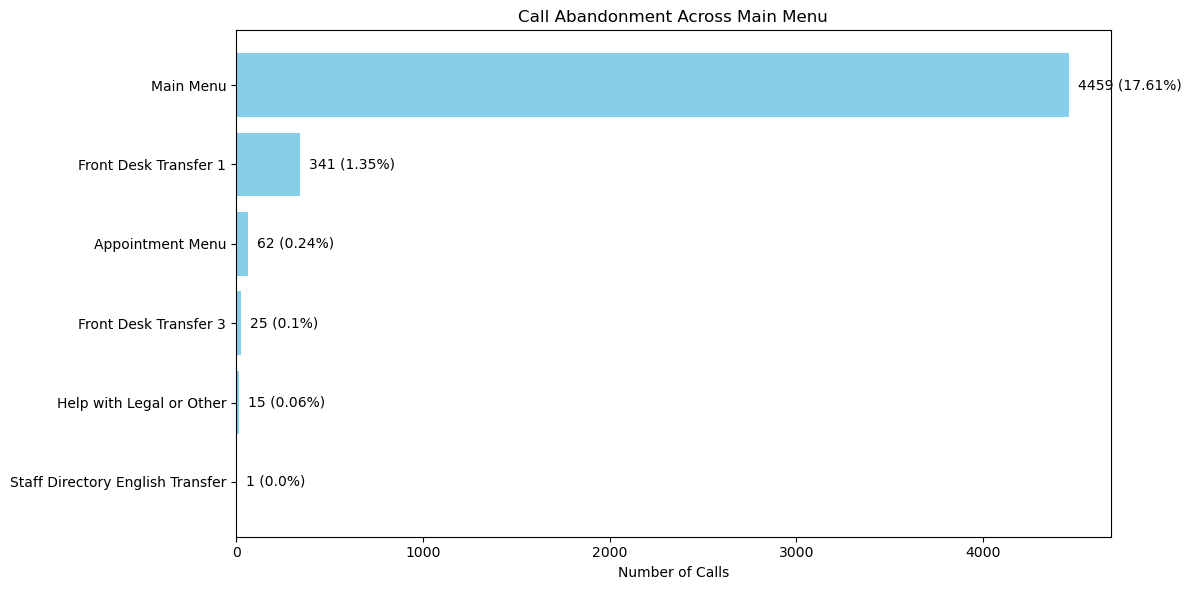

In [187]:
import matplotlib.pyplot as plt

# --- Data ---
activities = [
    'Front Desk Transfer 1',
    'Front Desk Transfer 3',
    'Staff Directory English Transfer',
    'Help with Legal or Other',
    'Appointment Menu',
    #'LanguageSelectionMenu',
    'Main Menu'
]

counts = [341, 25, 1, 15, 62, #9014, 
          4459]
total_calls = 25317

# --- Calculate percentages ---
percents = [round(c / total_calls * 100, 2) for c in counts]

# --- Sort by counts ascending ---
sorted_pairs = sorted(zip(counts, activities, percents))
sorted_counts, sorted_activities, sorted_percents = zip(*sorted_pairs)

# --- Plot horizontal bar chart ---
plt.figure(figsize=(12,6))
plt.barh(sorted_activities, sorted_counts, color='skyblue')

# Annotate counts and percentages
for i, (c, p) in enumerate(zip(sorted_counts, sorted_percents)):
    plt.text(c + 50, i, f"{c} ({p}%)", va='center')



plt.xlabel('Number of Calls')
plt.title('Call Abandonment Across Main Menu')
plt.tight_layout()
plt.show()


In [181]:
### SANITY CHECKS BELOW
# 
# 
df_main_ended[df_main_ended['call_id'] == 35276]

,call_id,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason,next_termination_reason,Last_EP_Name,ended_in_main_ep,Last_Activity
464093,35276,62a8be8f-1b95-49f8-bf01-609620ac6b22,Main Number Telephony EP,NaN,NaN,2025-07-29 12:58:55,NaN,NaN,NaN,NaN,Main Number Telephony EP,Yes,LanguageSelectionMenu
464094,35276,62a8be8f-1b95-49f8-bf01-609620ac6b22,NaN,LACMain,NaN,2025-07-29 12:58:55,NaN,NaN,NaN,NaN,Main Number Telephony EP,Yes,LanguageSelectionMenu
464095,35276,62a8be8f-1b95-49f8-bf01-609620ac6b22,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-07-29 12:58:55,NaN,NaN,NaN,NO_ANSWER_FROM_CUSTOMER,Main Number Telephony EP,Yes,LanguageSelectionMenu
464096,35276,62a8be8f-1b95-49f8-bf01-609620ac6b22,Main Number Telephony EP,NaN,NaN,2025-07-29 12:58:55,NaN,NaN,NO_ANSWER_FROM_CUSTOMER,NaN,Main Number Telephony EP,Yes,LanguageSelectionMenu


In [179]:
df_main_ended.loc[
    df_main_ended['Termination Reason'] == 'NO_ANSWER_FROM_CUSTOMER', 
    'call_id'
].unique()




array([  113,   168,   216,   323,   931,  1632,  1882,  1896,  2807,
        3030,  3056,  3122,  3127,  3486,  3553,  4100,  4467,  4496,
        4578,  4786,  5067,  5283,  5604,  5641,  5732,  5912,  6162,
        6560,  6596,  6771,  7036,  7063,  7094,  7312,  8032,  8174,
        8190,  8555,  8786,  8875,  9206,  9279,  9556,  9977, 10073,
       10557, 11185, 11300, 11633, 11784, 11789, 11790, 12080, 12460,
       12708, 12714, 12770, 13095, 13247, 13631, 13722, 13807, 13857,
       13949, 14138, 14207, 14362, 14375, 14413, 14733, 14749, 15021,
       15053, 15434, 15527, 15935, 15963, 16109, 16231, 16351, 16982,
       17094, 17250, 17610, 17849, 18483, 18532, 18791, 19053, 19072,
       19460, 19639, 20098, 20152, 20277, 20303, 20411, 20607, 20879,
       20989, 21121, 21222, 21479, 21488, 21539, 22072, 22324, 22569,
       22880, 22898, 23077, 23326, 23490, 23525, 23648, 23763, 23902,
       23970, 24070, 24149, 24451, 24556, 24925, 25119, 25424, 25590,
       25615, 25878,

In [ ]:
'''
"If you are calling to cancel or reschedule an appointment, press 1. 
If you are trying to reach the attorney or paralegal you are already working with, press 2.
If you are calling for help with a legal problem that you have not talked to us about yet, press 3.
If you would like to hear about how to meet with a free lawyer in one of our neighborhood clinics, press 4. 
To hear about our compliment or complaint procedures, press 5.
For our staff directory press 6. If you would like to hear our address, fax number, or office hours, press 7.
If you are calling for any other reason, press 8. 
To repeat these options, press the pound key. "
'''